In [50]:
def dy_dx(x):
    return 2*x

In [51]:
dy_dx(3)

6

In [52]:
import torch

In [75]:
x=torch.tensor(3.0,requires_grad=True)


In [77]:
y=x**2

In [ ]:
x

In [76]:
y

tensor(0.)

In [78]:
y.backward()

In [ ]:
print(x.grad)

In [56]:
# differentation of y=x^2 , z= sin(y) find dz/dx
import math
def dz_dx(x):
    return 2 * x * math.cos(x**2)

In [57]:
dz_dx(3)

-5.466781571308061

In [58]:
# differentation of y=x^2 , z= sin(y) find dz/dx
# using pytorch
x=torch.tensor(3.0,requires_grad=True)

#defining the functions
y=x**2
z=torch.sin(y)

In [59]:
z.backward()

In [60]:
x.grad

tensor(-5.4668)

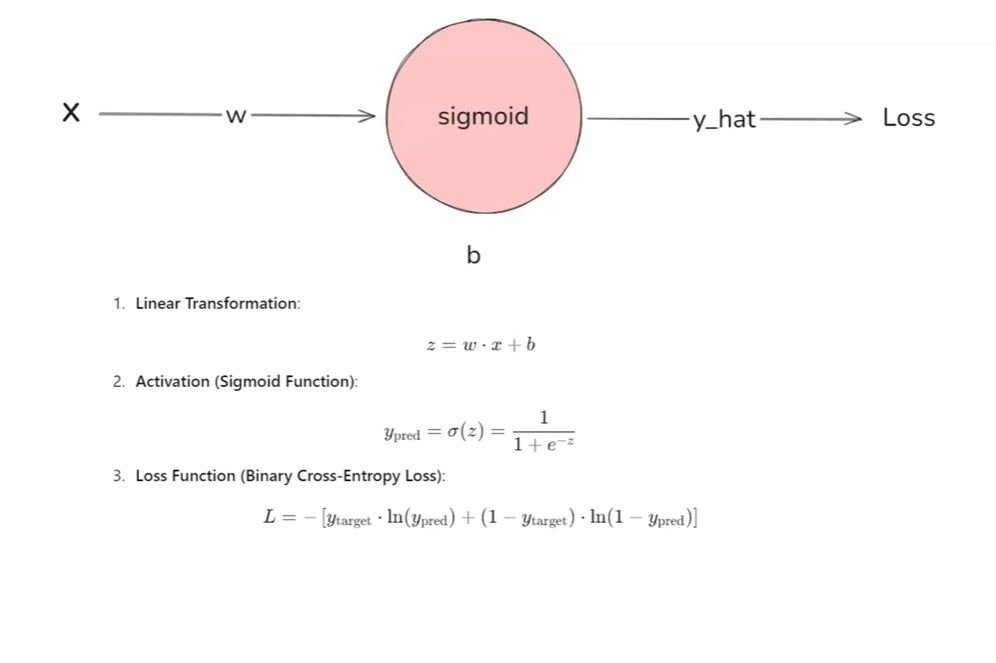

In [61]:
import torch
#Inputs
x=torch.tensor(6.7) #input feature
y=torch.tensor(0.0)

w=torch.tensor(1.0)  # initial weight
b=torch.tensor(0.0)  # Bias

In [62]:
#Binary Cross-Entrophy loss for scalar
def binary_cross_entrophy(prediction,target):
    epsilon= 1e-8 # to prevent log(0)
    prediction = torch.clamp(prediction,epsilon,1-epsilon)
    return -(target*torch.log(prediction)+(1-target)*torch.log(1-prediction))

In [63]:
# Forward pass
z= w * x + b #weighted sum (linear part)
y_pred=torch.sigmoid(z)  #predicted probability

loss=binary_cross_entrophy(y_pred,y)

In [64]:
loss

tensor(6.7012)

In [65]:
#calculating derivatives :
dloss_dy_pred=(y_pred-y)/(y_pred*(1-y_pred))

# 2.
dy_pred_dz=y_pred*(1-y_pred)

dz_dw=x
dz_db=1

dL_dw=dloss_dy_pred*dy_pred_dz*dz_dw
dl_db=dloss_dy_pred*dy_pred_dz*dz_db


In [66]:
print(f"Manual Gradient of loss w.r.t weight (dw): {dL_dw}")
print(f"Manual Gradient of loss w.r.t bias (db): {dl_db}")

Manual Gradient of loss w.r.t weight (dw): 6.691762447357178
Manual Gradient of loss w.r.t bias (db): 0.998770534992218


In [67]:
## Using pytorch for finding gradients with respect to weight and bias
x=torch.tensor(6.7)
y=torch.tensor(0.0)

In [68]:
w=torch.tensor(1.0,requires_grad=True)
b=torch.tensor(0.0,requires_grad=True)

In [69]:
print(w,b)

tensor(1., requires_grad=True) tensor(0., requires_grad=True)


In [70]:
#defining relationship between w , x , b
z=w*x + b
z


tensor(6.7000, grad_fn=<AddBackward0>)

In [71]:
y_pred=torch.sigmoid(z)
y_pred

tensor(0.9988, grad_fn=<SigmoidBackward0>)

In [72]:
loss=binary_cross_entrophy(y_pred,y)
loss

tensor(6.7012, grad_fn=<NegBackward0>)

In [73]:
# You are encountering this error because the computation graph is freed after a backward pass.
# To fix this, re-run the cells that define your tensors and calculations (z, y_pred, loss)
# before calling loss.backward() again.
loss.backward()

In [79]:
print(w.grad)
print(b.grad)

tensor(6.6918)
tensor(0.9988)


In [ ]:
x=torch.tensor([])

In [80]:
## Using vectors in autograd
x=torch.tensor([1.0,2.0,3.0],requires_grad=True)
x

tensor([1., 2., 3.], requires_grad=True)

In [81]:
y=(x**2).mean()
y

tensor(4.6667, grad_fn=<MeanBackward0>)

In [86]:
y.backward()

In [87]:
print(x.grad)

tensor([0.6667, 1.3333, 2.0000])


In [88]:
#Clearing Gradients
x=torch.tensor(2.0, requires_grad=True)
x

tensor(2., requires_grad=True)

In [89]:
#function of x and y
y=x**2
y

tensor(4., grad_fn=<PowBackward0>)

In [90]:
y.backward()

In [91]:
x.grad

tensor(4.)

In [92]:
x.grad.zero_()

tensor(0.)

In [93]:
#disable gradient tracking
x=torch.tensor(2.0,requires_grad=True)
y=x**2
y.backward()

In [94]:
x.grad

tensor(4.)

In [95]:
# some options to disable gradient tracking
# option 1 -> requires_grad_(False)
#option 2 -> detach()
#option 3 -> torch.no_grad()

In [96]:
#option 1
x.requires_grad_(False ) # last underscore is for implace

tensor(2.)

In [99]:
x=torch.tensor(2.0,requires_grad=True)

In [100]:
#option 3 (no_grad)
with torch.no_grad():
    y=x**2

In [103]:
y.grad